In [20]:
import s3fs
import polars as pl

fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

In [21]:
with fs.open("s3://projet-ape/data/08112022_27102024/naf2025/split/df_train.parquet", "rb") as f:
    df = pl.read_parquet(f)

    df = df.rename(mapping={"nace2025": "code", "libelle": "label"})[["code", "label"]]
    df = df.with_columns(
        (pl.col("code").str.slice(0, 2) + "." + pl.col("code").str.slice(2)).alias("code")
    )

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_293989/1896350165.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(code_prop["rang"], code_prop["log10_proportion"], label="$\mathcal{X}_{train\_real}$ ($\log10$)", color="#1f77b4", lw=2)
/tmp/ipykernel_293989/1896350165.py:56: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
/tmp/ipykernel_293989/1896350165.py:61: SyntaxWarning: invalid escape sequence '\l'
  texte_equation = f"Body equation :\n$\log(Y) = {pente:.4f} \cdot X + {intercept:.2f}$"
/tmp/ipykernel_293989/1896350165.py:61: SyntaxWarning

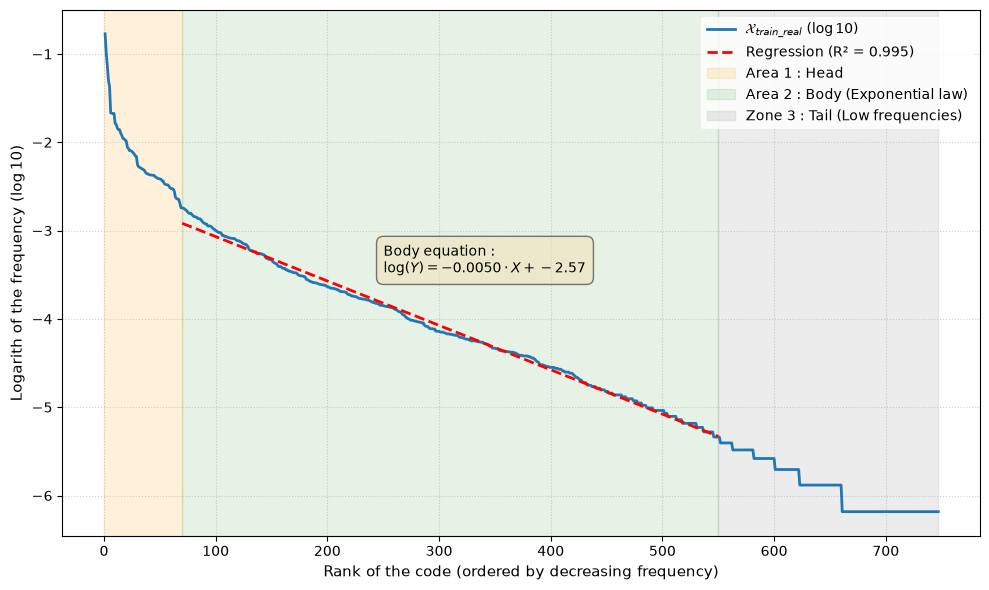

In [54]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. PREPROCESSING
# ==========================================

code_prop = df["code"].value_counts(normalize=True).sort(by="proportion", descending=True)
code_prop = code_prop.with_columns(pl.col("proportion").log10().alias("log10_proportion"))
rangs = np.arange(1,748)
code_prop = code_prop.with_columns(pl.Series("rang", values=rangs))

# ==========================================
# 2. DÉFINITION DES ZONES & RÉGRESSION
# ==========================================
# Ajustez ces indices selon votre courbe exacte
INDEX_DEBUT_CORPS = 70
INDEX_FIN_CORPS = 550

# Filtrage de la zone centrale pour le FIT
code_prop_reg = code_prop.filter((pl.col("rang") >= INDEX_DEBUT_CORPS) & (pl.col("rang") <= INDEX_FIN_CORPS))

X = code_prop_reg.select("rang").to_numpy()
y = code_prop_reg.select("log10_proportion").to_numpy()

# Ajustement du modèle
modele = LinearRegression()
modele.fit(X, y)

# Prédiction sur la zone du corps pour affichage
y_pred = modele.predict(X)
pente = modele.coef_[0][0]
intercept = modele.intercept_[0]
r_deux = modele.score(X, y)

# ==========================================
# 3. VISUALISATION GRAPHIQUE
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# Tracé de la courbe globale
plt.plot(code_prop["rang"], code_prop["log10_proportion"], label="$\mathcal{X}_{train\_real}$ ($\log10$)", color="#1f77b4", lw=2)

# Tracé de la droite de régression sur la zone du corps
plt.plot(X, y_pred, label=f"Regression (R² = {r_deux:.3f})", color="red", linestyle="--", lw=2)

# Coloration des zones pour la présentation
plt.axvspan(0, INDEX_DEBUT_CORPS, color="orange", alpha=0.15, label="Area 1 : Head")
plt.axvspan(INDEX_DEBUT_CORPS, INDEX_FIN_CORPS, color="green", alpha=0.1, label="Area 2 : Body (Exponential law)")
plt.axvspan(INDEX_FIN_CORPS, code_prop["rang"].max(), color="gray", alpha=0.15, label="Zone 3 : Tail (Low frequencies)")

# Habillage du graphique
plt.xlabel("Rank of the code (ordered by decreasing frequency)", fontsize=11)
plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.6)

# Affichage de l'équation dans un coin du graphique
texte_equation = f"Body equation :\n$\log(Y) = {pente:.4f} \cdot X + {intercept:.2f}$"
plt.text(0.35, 0.5, texte_equation, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

In [23]:
code_count = df["code"].value_counts(normalize=False).sort(by="count", descending=True)
len(code_count.filter(pl.col("count") <= 50))

360

In [24]:
code_count.select(pl.median("count"))

count
f64
59.0


In [25]:
df["label"].is_duplicated().sum()/df["label"].count()

0.6803641906742609

In [9]:
synth_path = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/2026-03-16_google-gemma-3-27b-it_temp14_fewshot6_exhaustive.parquet"

with fs.open(synth_path, "rb") as f:
    df_synth = pl.read_parquet(f)

In [15]:
synth_code_count = df_synth["code"].value_counts().sort(by="count", descending=True)

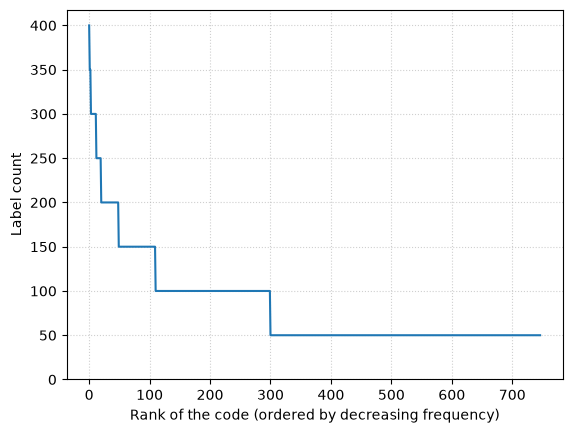

In [31]:
plt.plot(range(747), synth_code_count["count"])
plt.yticks(range(0, 450, 50))
plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Rank of the code (ordered by decreasing frequency)")
plt.ylabel("Label count")
plt.show()

In [32]:
with fs.open("s3://projet-ape/data/08112022_27102024/naf2025/split/df_test.parquet", "rb") as f:
    df_test = pl.read_parquet(f)

    df_test = df_test.rename(mapping={"nace2025": "code", "libelle": "label"})[["code", "label"]]
    df_test = df_test.with_columns(
        (pl.col("code").str.slice(0, 2) + "." + pl.col("code").str.slice(2)).alias("code")
    )

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_293989/2157404728.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(code_prop_test["rang"], code_prop_test["log10_proportion"], label="$\mathcal{X}_{test}$ ($\log10$)", color="#1f77b4", lw=2)
/tmp/ipykernel_293989/2157404728.py:56: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
/tmp/ipykernel_293989/2157404728.py:61: SyntaxWarning: invalid escape sequence '\l'
  texte_equation = f"Body equation :\n$\log(Y) = {pente:.4f} \cdot X + {intercept:.2f}$"
/tmp/ipykernel_293989/2157404728.py:61: SyntaxWarn

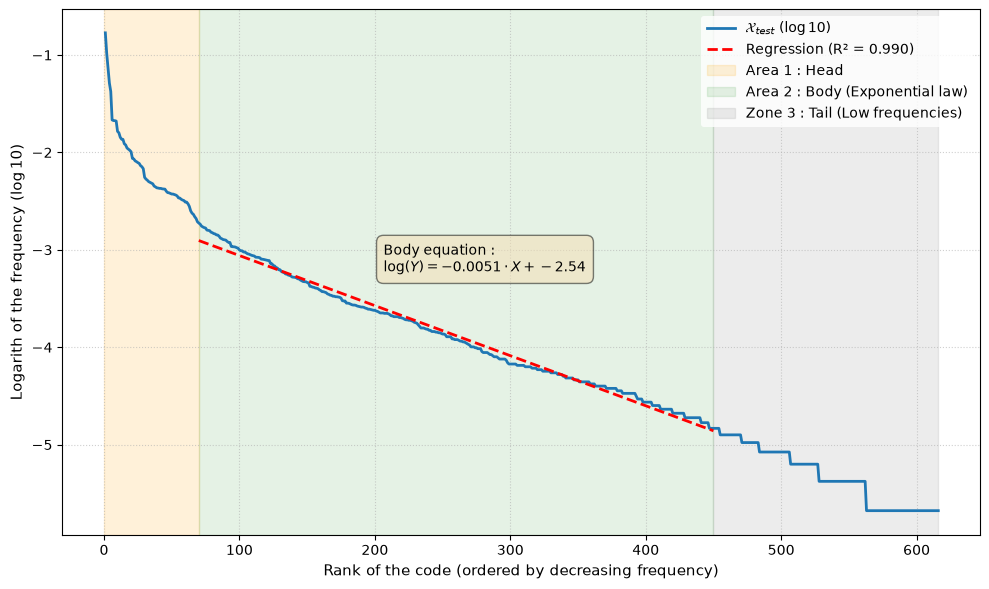

In [35]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. PREPROCESSING
# ==========================================

code_prop_test = df_test["code"].value_counts(normalize=True).sort(by="proportion", descending=True)
code_prop_test = code_prop_test.with_columns(pl.col("proportion").log10().alias("log10_proportion"))
rangs_test = np.arange(1,617)
code_prop_test = code_prop_test.with_columns(pl.Series("rang", values=rangs_test))

# ==========================================
# 2. DÉFINITION DES ZONES & RÉGRESSION
# ==========================================
# Ajustez ces indices selon votre courbe exacte
INDEX_DEBUT_CORPS = 70
INDEX_FIN_CORPS = 450

# Filtrage de la zone centrale pour le FIT
code_prop_test_reg = code_prop_test.filter((pl.col("rang") >= INDEX_DEBUT_CORPS) & (pl.col("rang") <= INDEX_FIN_CORPS))

X = code_prop_test_reg.select("rang").to_numpy()
y = code_prop_test_reg.select("log10_proportion").to_numpy()

# Ajustement du modèle
modele = LinearRegression()
modele.fit(X, y)

# Prédiction sur la zone du corps pour affichage
y_pred = modele.predict(X)
pente = modele.coef_[0][0]
intercept = modele.intercept_[0]
r_deux = modele.score(X, y)

# ==========================================
# 3. VISUALISATION GRAPHIQUE
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# Tracé de la courbe globale
plt.plot(code_prop_test["rang"], code_prop_test["log10_proportion"], label="$\mathcal{X}_{test}$ ($\log10$)", color="#1f77b4", lw=2)

# Tracé de la droite de régression sur la zone du corps
plt.plot(X, y_pred, label=f"Regression (R² = {r_deux:.3f})", color="red", linestyle="--", lw=2)

# Coloration des zones pour la présentation
plt.axvspan(0, INDEX_DEBUT_CORPS, color="orange", alpha=0.15, label="Area 1 : Head")
plt.axvspan(INDEX_DEBUT_CORPS, INDEX_FIN_CORPS, color="green", alpha=0.1, label="Area 2 : Body (Exponential law)")
plt.axvspan(INDEX_FIN_CORPS, code_prop_test["rang"].max(), color="gray", alpha=0.15, label="Zone 3 : Tail (Low frequencies)")

# Habillage du graphique
plt.xlabel("Rank of the code (ordered by decreasing frequency)", fontsize=11)
plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.6)

# Affichage de l'équation dans un coin du graphique
texte_equation = f"Body equation :\n$\log(Y) = {pente:.4f} \cdot X + {intercept:.2f}$"
plt.text(0.35, 0.5, texte_equation, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

In [131]:
head = code_prop.filter(pl.col("rang") < INDEX_DEBUT_CORPS).select("code").to_numpy().flatten()
body = code_prop.filter((pl.col("rang") >= INDEX_DEBUT_CORPS) &  (pl.col("rang") <= INDEX_FIN_CORPS)).select("code").to_numpy().flatten()
tail = code_prop.filter(pl.col("rang") > INDEX_FIN_CORPS).select("code").to_numpy().flatten()

In [ ]:
bucket_path = "s3://mateom/graal"

data_to_save = {
    "head": head,
    "body": body,
    "tail": tail
}

with fs.open(f"{bucket_path}/distribution_zones.npz", "wb") as f:
    np.savez_compressed(f, **data_to_save)

In [132]:
print(f"Ratio of codes included in head: {len(df_test.filter(pl.col("code").is_in(head))["code"].unique())/len(head):0.3f}")
print(f"Ratio of codes included in body: {len(df_test.filter(pl.col("code").is_in(body))["code"].unique())/len(body):0.3f}")
print(f"Ratio of codes included in tail: {len(df_test.filter(pl.col("code").is_in(tail))["code"].unique())/len(tail):0.3f}")

Ratio of codes included in head: 1.000
Ratio of codes included in body: 0.994
Ratio of codes included in tail: 0.350


In [133]:
print("Number of missing codes of body in test dataset:", len(set(body) - set(df_test.filter(pl.col("code").is_in(body))["code"].unique().to_numpy())))

Number of missing codes of body in test dataset: 3


<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_293989/3374384536.py:55: SyntaxWarning: invalid escape sequence '\m'
  label="Codes corresponding to '" + group_name + "' in $\mathcal{X}_{train\_real}$",
/tmp/ipykernel_293989/3374384536.py:61: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Rank of the code (ordered by decreasing frequency) in $\mathcal{X}_{test}$", fontsize=11)
/tmp/ipykernel_293989/3374384536.py:62: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)


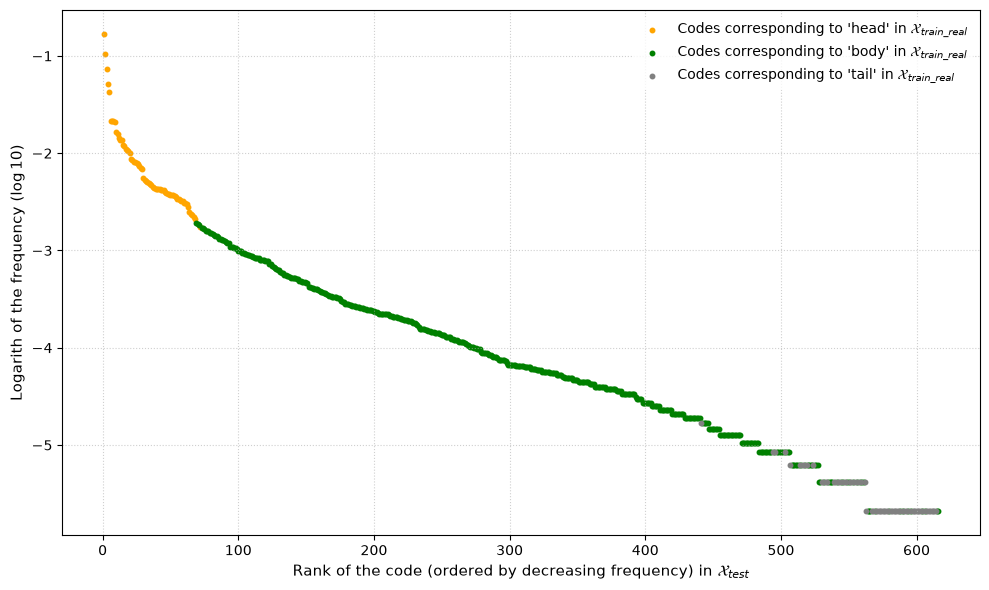

In [100]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def color_codes(x):
    match x:
        case _ if x in head:
            return "orange"
        case _ if x in body:
            return "green"
        case _ if x in tail:
            return "gray"
        case _:
            return "unknown"

def map_codes(x):
    match x:
        case _ if x in head:
            return "head"
        case _ if x in body:
            return "body"
        case _ if x in tail:
            return "tail"
        case _:
            return "unknown"

# ==========================================
# 1. PREPROCESSING
# ==========================================

code_prop_test = df_test["code"].value_counts(normalize=True).sort(by="proportion", descending=True)
code_prop_test = code_prop_test.with_columns(pl.col("proportion").log10().alias("log10_proportion"))
rangs_test = np.arange(1,617)
code_prop_test = code_prop_test.with_columns(pl.Series("rang", values=rangs_test))
code_prop_test = code_prop_test.with_columns(pl.col("code").map_elements(color_codes).alias("color"))
code_prop_test = code_prop_test.with_columns(pl.col("code").map_elements(map_codes).alias("group"))


# ==========================================
# 2. VISUALISATION GRAPHIQUE
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# Tracé de la courbe globale
color_ids = code_prop_test["color"]
for group_name, group_df in code_prop_test.partition_by("group", as_dict=True).items():
    
    group_color = group_df["color"][0]
    group_name = group_name[0]

    plt.scatter(
        group_df["rang"], 
        group_df["log10_proportion"], 
        label="Codes corresponding to '" + group_name + "' in $\mathcal{X}_{train\_real}$",
        color=group_color,
        lw=2, 
        s=5
    )
# Habillage du graphique
plt.xlabel("Rank of the code (ordered by decreasing frequency) in $\mathcal{X}_{test}$", fontsize=11)
plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_293989/1203669756.py:36: SyntaxWarning: invalid escape sequence '\m'
  label=["Codes corresponding to 'body' in $\mathcal{X}_{train\_real}$", "Codes corresponding to 'tail' in $\mathcal{X}_{train\_real}$"],
/tmp/ipykernel_293989/1203669756.py:36: SyntaxWarning: invalid escape sequence '\m'
  label=["Codes corresponding to 'body' in $\mathcal{X}_{train\_real}$", "Codes corresponding to 'tail' in $\mathcal{X}_{train\_real}$"],


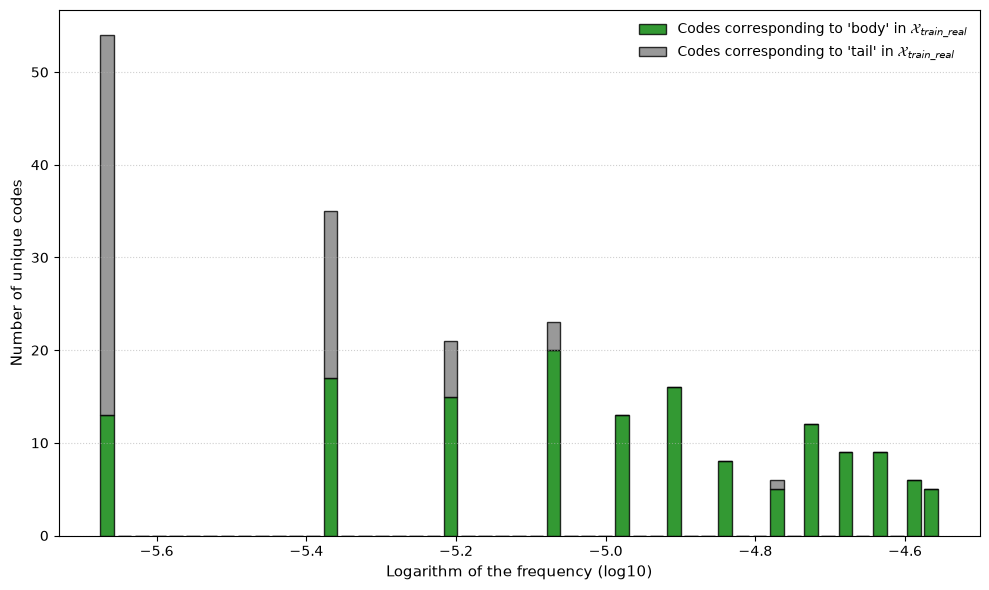

In [138]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# [Tes fonctions color_codes et map_codes restent identiques]

# ==========================================
# 1. PREPROCESSING
# ==========================================

code_prop_test = df_test["code"].value_counts(normalize=True).sort(by="proportion", descending=True)
code_prop_test = code_prop_test.with_columns(pl.col("proportion").log10().alias("log10_proportion"))
rangs_test = np.arange(1, len(code_prop_test) + 1)
code_prop_test = code_prop_test.with_columns(pl.Series("rang", values=rangs_test))
code_prop_test = code_prop_test.filter(pl.col("rang") >= 400)

code_prop_test = code_prop_test.with_columns(pl.col("code").map_elements(map_codes).alias("group"))

body_counts = code_prop_test.filter(pl.col("group") == "body")["log10_proportion"].to_list()
tail_counts = code_prop_test.filter(pl.col("group") == "tail")["log10_proportion"].to_list()


# ==========================================
# 2. VISUALISATION GRAPHIQUE (HISTOGRAMME EMPILÉ)
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

min_val = min(body_counts + tail_counts)
max_val = max(body_counts + tail_counts)
bins = np.linspace(min_val - 1e-6, max_val + 0.01)

plt.hist(
    [body_counts, tail_counts], 
    bins=bins, 
    stacked=True, 
    label=["Codes corresponding to 'body' in $\mathcal{X}_{train\_real}$", "Codes corresponding to 'tail' in $\mathcal{X}_{train\_real}$"], 
    color=["green", "gray"],
    rwidth=0.8,
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Logarithm of the frequency (log10)", fontsize=11)
plt.ylabel("Number of unique codes", fontsize=11)

plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()